# The Biopython library: https://biopython.org/

**GENE 211: Genomics, Intermediate Section<br>
Instructor:** Veronica Behrens<br>

<i>**Note:** Students were provided with a partially completed version of this Notebook to follow along as the instructor coded in real time and to work through practice problems independently and in small groups. The version shown here reflects the fully completed notebook after instruction.<i>

In [5]:
from Bio.Seq import Seq

dna = Seq('ATCGATCGGGCTATAAAAGCGCTGAC')
print(dna.complement())
dna

TAGCTAGCCCGATATTTTCGCGACTG


Seq('ATCGATCGGGCTATAAAAGCGCTGAC')

# Installing Biopython

**For conda:**<br />
conda install -c anaconda biopython

**MacOS without Anaconda:**<br />
pip3 install biopython

**Windows without Anaconda:**<br />
pip install biopython

# Let's practice with Biopython

In [6]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils import seq3
from Bio.SeqUtils import GC
% pylab inline

# if % pylab inline or % matplotlib inline doesn't work for you, use this:
#import matplotlib
#import pyplot as plt

# Dowload this FASTA file from Canvas
IN_FILE_NAME = './ls_orchid.fasta'

Populating the interactive namespace from numpy and matplotlib


# Print out just the sequence IDs (without using Biopython)

In [7]:
with open(IN_FILE_NAME, 'r') as inFile:
    for line in inFile:
        line = line.strip()
        if line.startswith('>'):
            #print(line)
            ID = line.split(' ')[0][1:]
            print(ID)

gi|2765658|emb|Z78533.1|CIZ78533
gi|2765657|emb|Z78532.1|CCZ78532
gi|2765656|emb|Z78531.1|CFZ78531
gi|2765655|emb|Z78530.1|CMZ78530
gi|2765654|emb|Z78529.1|CLZ78529
gi|2765652|emb|Z78527.1|CYZ78527
gi|2765651|emb|Z78526.1|CGZ78526
gi|2765650|emb|Z78525.1|CAZ78525
gi|2765649|emb|Z78524.1|CFZ78524
gi|2765648|emb|Z78523.1|CHZ78523
gi|2765647|emb|Z78522.1|CMZ78522
gi|2765646|emb|Z78521.1|CCZ78521
gi|2765645|emb|Z78520.1|CSZ78520
gi|2765644|emb|Z78519.1|CPZ78519
gi|2765643|emb|Z78518.1|CRZ78518
gi|2765642|emb|Z78517.1|CFZ78517
gi|2765641|emb|Z78516.1|CPZ78516
gi|2765640|emb|Z78515.1|MXZ78515
gi|2765639|emb|Z78514.1|PSZ78514
gi|2765638|emb|Z78513.1|PBZ78513
gi|2765637|emb|Z78512.1|PWZ78512
gi|2765636|emb|Z78511.1|PEZ78511
gi|2765635|emb|Z78510.1|PCZ78510
gi|2765634|emb|Z78509.1|PPZ78509
gi|2765633|emb|Z78508.1|PLZ78508
gi|2765632|emb|Z78507.1|PLZ78507
gi|2765631|emb|Z78506.1|PLZ78506
gi|2765630|emb|Z78505.1|PSZ78505
gi|2765629|emb|Z78504.1|PKZ78504
gi|2765628|emb|Z78503.1|PCZ78503
gi|2765627

# Using Biopython...
1. Print out just the sequence IDs.<br />
2. Print out just the DNA sequences.<br />
3. Print out the ID of the sequence followed by the amino acid translation of the DNA sequence.<br />
4. Change the 1-letter amino acid codes to the 3-letter amino acid codes (RNKV --> ArgAsnLysVal).<br />

In [8]:
for rec in SeqIO.parse(IN_FILE_NAME, 'fasta'):
    #print(rec.id) # print the IDs
    #print(rec.seq) # print the sequence
    #print(rec.seq.translate()) # print the translated sequence (1-letter AA codes)
    print(seq3(rec.seq.translate())) # print the translated sequence (3-letter AA codes)
    print()

...



/anaconda3/lib/python3.6/site-packages/Bio/Seq.py:2576: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  BiopythonWarning)


# Make a list of the sequence lengths (without using Biopython).
Find and print the length of the shortest sequence and the length of the longest sequence.

In [9]:
lengths = []
length = 0

with open(IN_FILE_NAME, 'r') as inFile:
    for line in inFile:
        line = line.strip()
        if line.startswith('>'):
            if length:
                lengths.append(length)
            length = 0   
        else:
            length += len(line)   
    lengths.append(length)
            
#print(lengths)
print(sorted(lengths))
print(len(lengths), min(lengths), max(lengths))

[572, 574, 587, 592, 592, 594, 610, 626, 629, 636, 641, 658, 688, 688, 694, 695, 696, 699, 700, 700, 702, 703, 704, 706, 709, 711, 712, 715, 716, 716, 718, 719, 720, 721, 726, 726, 727, 727, 728, 730, 730, 730, 731, 731, 732, 732, 733, 733, 733, 735, 736, 737, 737, 738, 738, 739, 740, 740, 740, 740, 740, 740, 740, 741, 742, 742, 743, 743, 743, 744, 744, 744, 744, 745, 745, 745, 745, 748, 750, 750, 752, 753, 753, 755, 757, 759, 762, 765, 767, 770, 774, 784, 788, 789]
94 572 789


# Using Biopython and matplotlib...
1. Make a list of the sequence lengths.  Find and print the length of the shortest sequence and the length of the longest sequence.<br />
2. Make a plot of the lengths of the sequences. (What type of plot would be best?)<br />
3. Change the number of bins in the histogram.<br />
4. Change the color of the bars of the histogram.<br />
5. Add a title and x and y axis labels.<br />

In [10]:
lengths = [len(rec) for rec in SeqIO.parse(IN_FILE_NAME, 'fasta')]
print(sorted(lengths))
print(len(lengths), min(lengths), max(lengths))

[572, 574, 587, 592, 592, 594, 610, 626, 629, 636, 641, 658, 688, 688, 694, 695, 696, 699, 700, 700, 702, 703, 704, 706, 709, 711, 712, 715, 716, 716, 718, 719, 720, 721, 726, 726, 727, 727, 728, 730, 730, 730, 731, 731, 732, 732, 733, 733, 733, 735, 736, 737, 737, 738, 738, 739, 740, 740, 740, 740, 740, 740, 740, 741, 742, 742, 743, 743, 743, 744, 744, 744, 744, 745, 745, 745, 745, 748, 750, 750, 752, 753, 753, 755, 757, 759, 762, 765, 767, 770, 774, 784, 788, 789]
94 572 789


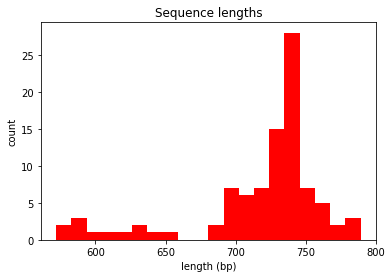

In [11]:
plt.hist(lengths, bins=20, color='r')
plt.title('Sequence lengths')
plt.xlabel('length (bp)')
plt.ylabel('count')
#plt.savefig('myFigure.jpeg', dpi=600)
plt.show()

# Make a list of the GC content of each sequence (without using Biopython).

In [12]:
gc_values = []
seq = ''

def gc_content(SEQ):
    GC = ((seq.upper().count('G') + seq.upper().count('C')) / len(seq)) * 100
    return GC

with open(IN_FILE_NAME, 'r') as inFile:
    for line in inFile:
        line = line.strip()
        if line.startswith('>'):
            if seq:
                gc = gc_content(seq)
                gc_values.append(gc)
            seq = '' 
        else:
            seq += line   
    gc = gc_content(seq)
    gc_values.append(gc)

gc_values = sorted(gc_values)
print(gc_values)

[32.33695652173913, 39.66836734693878, 43.296089385474865, 47.58064516129033, 47.7027027027027, 47.88540245566166, 48.472775564409034, 48.69186046511628, 48.78048780487805, 49.03581267217631, 49.07010014306152, 49.158249158249156, 49.17355371900827, 49.261744966442954, 49.38941655359565, 49.39434724091521, 49.43019943019943, 49.53519256308101, 49.734042553191486, 49.857142857142854, 49.86486486486486, 49.865591397849464, 50.0, 50.0, 50.0, 50.0, 50.0, 50.08517887563884, 50.14044943820225, 50.17482517482518, 50.3392130257802, 50.34106412005457, 50.352609308885754, 50.403225806451616, 50.40431266846361, 50.409836065573764, 50.41095890410959, 50.42613636363637, 50.46979865771812, 50.47361299052774, 50.50675675675676, 50.54054054054053, 50.56657223796034, 50.6056527590848, 50.64748201438849, 50.69637883008357, 50.738255033557046, 50.7482993197279, 50.75034106412005, 50.762829403606105, 50.76923076923077, 50.821917808219176, 50.821917808219176, 50.83333333333333, 50.857142857142854, 50.85803

# Using Biopython and matplotlib...
1. Make a list of the GC content of each sequence.<br />
2. Plot all the GC content values. (What type of plot would be best?)

In [13]:
gc_values = sorted([GC(rec.seq) for rec in SeqIO.parse(IN_FILE_NAME, 'fasta')])
print(gc_values)

[32.33695652173913, 39.66836734693877, 43.29608938547486, 47.58064516129032, 47.7027027027027, 47.88540245566166, 48.472775564409034, 48.69186046511628, 48.78048780487805, 49.035812672176306, 49.07010014306152, 49.158249158249156, 49.17355371900826, 49.261744966442954, 49.38941655359566, 49.39434724091521, 49.43019943019943, 49.53519256308101, 49.734042553191486, 49.857142857142854, 49.86486486486486, 49.865591397849464, 50.0, 50.0, 50.0, 50.0, 50.0, 50.08517887563884, 50.140449438202246, 50.17482517482517, 50.33921302578019, 50.34106412005457, 50.352609308885754, 50.403225806451616, 50.40431266846361, 50.40983606557377, 50.41095890410959, 50.42613636363637, 50.46979865771812, 50.47361299052774, 50.50675675675676, 50.54054054054054, 50.56657223796034, 50.60565275908479, 50.64748201438849, 50.69637883008357, 50.738255033557046, 50.74829931972789, 50.75034106412006, 50.762829403606105, 50.76923076923077, 50.821917808219176, 50.821917808219176, 50.833333333333336, 50.857142857142854, 50.8

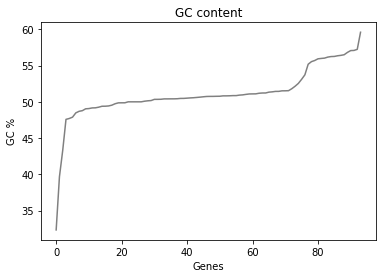

In [14]:
plt.plot(gc_values, color = 'gray')
plt.title('GC content')
plt.xlabel('Genes')
plt.ylabel('GC %')
plt.show()